# INTELIGENCIA ARTIFICIAL APLICADA A INTERNET DE LAS COSAS
# Nombres: Gissela Tasiguano Y Ariel Gámez
## PRACTICA 3: REDES NEURONALES Y DEEP LEARNING

**Instalación**

Se necesita la Scikit-learn que ya se instaló en las anteriores prácticas

https://scikit-learn.org/

  ## Parte A: Perceptrón Multicapa

En esta parte de la práctica se trabaja con redes neuronales utilizando la librería **Scikit‑learn**, centrándonos en el modelo **Multi‑Layer Perceptron (MLP)**. El objetivo es generar un conjunto de datos sintético basado en temperatura y humedad, clasificar entre *discomfort* (1) y *comfort* (0), entrenar un MLP y evaluar su rendimiento.

A lo largo del notebook se desarrollarán los siguientes puntos:

1. Generación de datos aleatorios (temperatura y humedad) y visualización de las clases.  
2. División del dataset en entrenamiento y evaluación.  
3. Entrenamiento de un MLP usando `MLPClassifier`.  
4. Aplicación del modelo entrenado sobre el conjunto de evaluación.  
5. Visualización de los resultados de clasificación.  
6. Cálculo de métricas: **precisión**, **recall** y **F1**.  
7. Pruebas con distintas configuraciones del MLP para evitar *overfitting*.  
8. Comparación de métricas entre configuraciones.  
9. Discusión final sobre cuál es la mejor configuración y por qué.

### Importación de librerías

En esta celda importamos todas las librerías necesarias para la práctica:

- **NumPy** para generar datos numéricos.
- **Matplotlib** para dibujar gráficas.
- **Scikit‑learn** para dividir los datos, entrenar el MLP y calcular métricas.
- **MLPClassifier** es el modelo de red neuronal que vamos a usar.
- **precision_score, recall_score, f1_score** nos permiten evaluar el rendimiento del modelo.

Estas librerías son esenciales para construir, entrenar y evaluar la red neuronal.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.preprocessing import StandardScaler

### 1. Generación del dataset (temperatura, humedad y etiquetas)

En esta celda generamos un conjunto de datos sintético con 2000 puntos.  
Cada punto tiene dos características:

- Temperatura (entre 0 y 40 grados)
- Humedad (entre 0 y 100%)

Definimos la etiqueta **discomfort (1)** cuando:
- la temperatura es mayor que 28  
- y la humedad es mayor que 60  

En caso contrario, la etiqueta es **comfort (0)**.

Este dataset simula condiciones ambientales y nos servirá para entrenar la red neuronal.


In [2]:
np.random.seed(0)
N = 2000

temperatura = np.random.uniform(0, 40, N)
humedad = np.random.uniform(0, 100, N)

# Regla simple para discomfort
y = ((temperatura > 28) & (humedad > 60)).astype(int)

X = np.column_stack((temperatura, humedad))


### 1.1 Visualización del dataset generado

En esta celda representamos los puntos generados:

- Los puntos **azules** representan condiciones de *comfort*.
- Los puntos **rojos** representan condiciones de *discomfort*.

La gráfica nos permite ver visualmente cómo se distribuyen los datos y cómo se separan las clases.


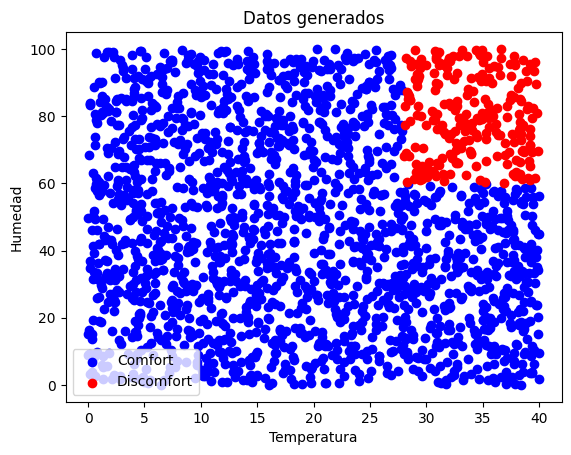

In [3]:
plt.scatter(temperatura[y==0], humedad[y==0], c='blue', label='Comfort')
plt.scatter(temperatura[y==1], humedad[y==1], c='red', label='Discomfort')
plt.xlabel("Temperatura")
plt.ylabel("Humedad")
plt.title("Datos generados")
plt.legend()
plt.show()


### 1.2 Gráfica de los datos generados

Esta gráfica muestra la distribución de los puntos del dataset sintético antes de entrenar cualquier modelo. Cada punto representa una combinación de temperatura y humedad:

- Los puntos **azules** corresponden a la clase *comfort* (etiqueta 0).
- Los puntos **rojos** corresponden a la clase *discomfort* (etiqueta 1).

La región de *discomfort* aparece concentrada en la zona de temperaturas altas y humedades altas, ya que esa es la regla que se utilizó para generar las etiquetas. Esta visualización permite entender la estructura del problema y comprobar que las clases están bien definidas.


### 2. División del dataset en entrenamiento y test

Dividimos los datos en dos subconjuntos:

- **70%** para entrenamiento
- **30%** para evaluación (test)

Una división común es 70% para entrenamiento y 30% para prueba, ya que ofrece un buen equilibrio: el modelo dispone de la mayoría de los datos para aprender patrones, mientras que el 30% restante permite evaluar su capacidad de generalización de forma fiable.

Además, al trabajar con problemas de clasificación, es fundamental que ambas particiones mantengan la misma distribución de clases que el conjunto original. Por ello se utiliza el parámetro **stratify=y**, que garantiza que tanto el conjunto de entrenamiento como el de prueba conserven las proporciones reales de cada clase. Esto evita que una clase quede sobrerrepresentada o infrarrepresentada en alguna de las particiones, lo cual podría sesgar el entrenamiento o producir métricas de evaluación poco realistas.


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y
)

# Normalización

La normalización es necesaria con variables temperatura y humedad, porque aunque ambas representen condiciones ambientales, sus escalas numéricas son muy diferentes. La humedad puede llegar a valores mucho más altos que la temperatura, y esto provoca que la red neuronal dé más importancia a la variable con números más grandes, no porque sea más relevante, sino por su escala. Al normalizar con StandardScaler, ambas variables quedan en un rango comparable, lo que permite que el modelo aprenda de forma equilibrada, más rápida y con mejores resultados.

In [5]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### 3. Entrena una red neuronal con el conjunto de entrenamiento

**ACTIVATION**:

**'relu'** : Rápida, sencilla, se utliza para problemas generales

**'tanh'**: Suave, simétrica, buena para fronteras curvas, para dataset pequeños

**SOLVER**

**'adam'**: Muy usado, robusto, bueno para datasets grandes.

**'lbfgs'**: Muy preciso, converge rápido en datasets pequeños.

**LEARNING RATE**

**'constant'**: Problemas simples, estables, sin ruido.

**'adaptative'**: Cuando quieres mas estabilidad y precisión.
    

In [6]:
clf = MLPClassifier(
    hidden_layer_sizes=(10, 5),
    activation='relu',
    solver='adam',
    learning_rate='adaptive',
    max_iter=1000,
    random_state=42
)

clf.fit(X_train, y_train)

MLPClassifier(hidden_layer_sizes=(10, 5), learning_rate='adaptive',
              max_iter=1000, random_state=42)

### 4. Aplica el modelo entrenado sobre el conjunto de evaluación

In [7]:
y_pred = clf.predict(X_test)

### 6. Muestra los resultados aplicados sobre el conjunto de evaluación. Se puede mostrar una gráfica como la anterior: puntos (temperatura y humedad) y su clasificación con MLP pintado de distinta manera (e.g. “x” o círculos).

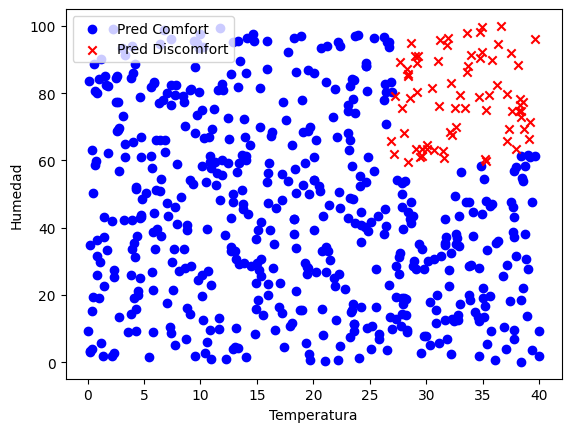

In [8]:
plt.scatter(X_test[y_pred==0][:,0], X_test[y_pred==0][:,1], marker='o', c='blue', label='Pred Comfort')
plt.scatter(X_test[y_pred==1][:,0], X_test[y_pred==1][:,1], marker='x', c='red', label='Pred Discomfort')
plt.xlabel("Temperatura")
plt.ylabel("Humedad")
plt.legend()
plt.show()


### 6. Cálculo de métricas

In [9]:
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Precisión:", precision)
print("Recall:", recall)
print("F1:", f1)

Precisión: 0.9027777777777778
Recall: 0.9420289855072463
F1: 0.9219858156028369


### 7. Para evitar “overfitting” habría que entrenar y validar los datos con conjuntos diferentes y con configuraciones de la red distintas. Prueba a mejorar la precisión de la red neuronal cambiando algunos de los parámetros que has aprendido y haciendo distintas particiones del dataset. Se deben probar al menos dos configuraciones distintas.


### Configuración A del MLP

En esta celda definimos la primera configuración de la red neuronal MLP:

- `hidden_layer_sizes=(8,4)`: dos capas ocultas con 8 y 4 neuronas.
- `activation='relu'`: función de activación ReLU.
- `solver='adam'`: optimizador Adam.
- `learning_rate='constant'`: tasa de aprendizaje fija.
- `max_iter=800`: máximo de iteraciones para entrenar.

Esta configuración es relativamente simple y nos servirá como punto de comparación.


In [10]:
clfA = MLPClassifier(
    hidden_layer_sizes=(8,4),
    activation='relu',
    solver='adam',
    learning_rate='constant',
    max_iter=800,
    random_state=0
)


### Entrenamiento del modelo A

Entrenamos el modelo MLP con los datos de entrenamiento.  
Durante este proceso, la red neuronal ajusta sus pesos internos para aprender la relación entre temperatura, humedad y la etiqueta de comfort/discomfort.


In [11]:
clfA.fit(X_train, y_train)


MLPClassifier(hidden_layer_sizes=(8, 4), max_iter=800, random_state=0)

### Interpretación de la salida del entrenamiento del modelo A

La tabla que aparece después de ejecutar `clfA.fit(X_train, y_train)` muestra la configuración final del modelo MLP una vez entrenado. Esta salida confirma que el entrenamiento se ha completado correctamente y detalla los parámetros con los que ha quedado configurada la red neuronal:

- **hidden_layer_sizes=(8, 4)** indica que el modelo tiene dos capas ocultas con 8 y 4 neuronas respectivamente.
- **max_iter=800** muestra el número máximo de iteraciones permitidas durante el entrenamiento.
- **random_state=0** asegura que los resultados sean reproducibles.
- Otros parámetros reflejan la configuración interna del modelo, como el solver utilizado, la función de activación y la regularización.

Esta salida no muestra métricas de rendimiento, sino únicamente la estructura final del modelo entrenado. Sirve para verificar que el modelo se ha ajustado correctamente y que los hiperparámetros establecidos se han aplicado.


### Predicción del modelo A

Usamos el modelo entrenado para predecir las etiquetas del conjunto de test.  
Estas predicciones se compararán con las etiquetas reales para evaluar el rendimiento.


In [12]:
y_predA = clfA.predict(X_test)


### Métricas del modelo A

Calculamos tres métricas importantes:

- **Precisión**: proporción de predicciones correctas entre las predicciones positivas.
- **Recall**: capacidad del modelo para detectar correctamente los casos de discomfort.
- **F1**: media armónica entre precisión y recall.

Estas métricas nos permiten evaluar la calidad del modelo.


In [13]:
print("CONFIGURACIÓN A")
print("Precisión:", precision_score(y_test, y_predA))
print("Recall:", recall_score(y_test, y_predA))
print("F1:", f1_score(y_test, y_predA))


CONFIGURACIÓN A
Precisión: 0.9387755102040817
Recall: 0.6666666666666666
F1: 0.7796610169491526


### Métricas de rendimiento de la Configuración A

Aquí se muestran las métricas de evaluación del modelo A:

- **Precisión**: mide cuántas de las predicciones positivas son correctas.
- **Recall**: mide cuántos casos reales de discomfort detecta el modelo.
- **F1**: combina precisión y recall en una sola medida equilibrada.

El modelo es muy preciso cuando predice positivos (0.93), lo que significa que casi no comete falsos positivos.

Sin embargo, no detecta todos los positivos reales (recall 0.66), lo que indica que está siendo conservador: solo predice positivo cuando está muy seguro.

El F1-score de 0.77 muestra que el rendimiento general es bueno, pero podría mejorar si aumentas la capacidad del modelo para encontrar más positivos.

### Visualización de resultados del modelo A

Representamos los puntos del conjunto de test coloreados según la predicción del modelo:

- Azul: predicción de comfort
- Rojo: predicción de discomfort

Esto nos permite ver visualmente cómo clasifica el modelo los datos.


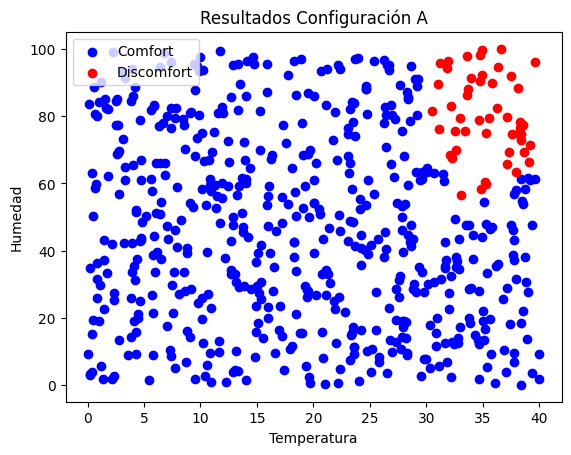

In [14]:
plt.scatter(X_test[y_predA==0][:,0], X_test[y_predA==0][:,1], c='blue', label='Comfort')
plt.scatter(X_test[y_predA==1][:,0], X_test[y_predA==1][:,1], c='red', label='Discomfort')
plt.xlabel("Temperatura")
plt.ylabel("Humedad")
plt.title("Resultados Configuración A")
plt.legend()
plt.show()


### Resultados de la Configuración A

La gráfica ayuda a entender por qué el modelo puede tener dificultades para detectar todos los casos de disconfort (como se vio en el recall):

La clase **disconfort** es mucho más pequeña y localizada, lo que la hace más difícil de aprender.

La clase **confort** es más dispersa y numerosa, por lo que el modelo tiende a predecirla con más facilidad.

La frontera entre ambas clases no es lineal ni simple; depende de la interacción entre temperatura y humedad.

Esto explica por qué el modelo puede ser muy preciso cuando predice disconfort, pero aun así dejar escapar algunos casos: la región crítica es estrecha y requiere que el modelo capture bien esa relación conjunta.


### Configuración B del MLP

Definimos una segunda configuración más compleja:

- `hidden_layer_sizes=(20,10,5)`: tres capas ocultas con más neuronas.
- `activation='tanh'`: función de activación tanh.
- `solver='lbfgs'`: optimizador basado en métodos quasi‑Newton.
- `alpha=1e-4`: regularización L2.
- `max_iter=2000`: más iteraciones para converger.

Esta configuración suele ofrecer mejor rendimiento en problemas simples.

**NOTA**: No especifica learning_rate → porque lbfgs no usa learning rate, ya que es un optimizador cuasi-Newton


In [15]:
clfB = MLPClassifier(
    hidden_layer_sizes=(20,10,5),
    activation='tanh',
    solver='lbfgs',
    alpha=1e-4,
    max_iter=2000,
    random_state=0
)


### Entrenamiento del modelo B

Entrenamos la segunda red neuronal con los mismos datos de entrenamiento.  
Al ser un modelo más complejo, puede capturar mejor la frontera entre comfort y discomfort.


In [16]:
clfB.fit(X_train, y_train)


MLPClassifier(activation='tanh', hidden_layer_sizes=(20, 10, 5), max_iter=2000,
              random_state=0, solver='lbfgs')

### Interpretación de la salida del entrenamiento del modelo B

La tabla que aparece después de ejecutar `clfB.fit(X_train, y_train)` muestra la configuración final del modelo MLP correspondiente a la Configuración B una vez completado el entrenamiento. Esta salida confirma que el modelo se ha entrenado correctamente y detalla los hiperparámetros con los que ha quedado configurado:

- **hidden_layer_sizes = (20, 10, 5)** indica que la red neuronal tiene tres capas ocultas con 20, 10 y 5 neuronas respectivamente.
- **activation = 'tanh'** especifica que la función de activación utilizada en las capas ocultas es *tanh*.
- **solver = 'lbfgs'** señala que se ha utilizado el optimizador L-BFGS, adecuado para problemas pequeños y que suele converger con precisión.
- **max_iter = 2000** indica el número máximo de iteraciones permitidas durante el entrenamiento.
- **random_state = 0** garantiza reproducibilidad en los resultados.

Esta salida no muestra métricas de rendimiento, sino únicamente la estructura y parámetros finales del modelo entrenado. Sirve para verificar que el modelo B se ha ajustado correctamente y que los hiperparámetros definidos se han aplicado como se esperaba.


### Predicción del modelo B

Obtenemos las predicciones del modelo B sobre el conjunto de test.  
Estas predicciones se compararán con las del modelo A.


In [17]:
y_predB = clfB.predict(X_test)


### Métricas del modelo B

Calculamos precisión, recall y F1 para esta segunda configuración.  
Compararemos estos valores con los obtenidos en la configuración A para determinar cuál funciona mejor.


In [18]:
print("CONFIGURACIÓN B")
print("Precisión:", precision_score(y_test, y_predB))
print("Recall:", recall_score(y_test, y_predB))
print("F1:", f1_score(y_test, y_predB))


CONFIGURACIÓN B
Precisión: 0.9701492537313433
Recall: 0.9420289855072463
F1: 0.9558823529411765


### Métricas de rendimiento de la Configuración B

La precisión es muy alta (0.97), lo que indica que casi todas las predicciones positivas que hace el modelo son correctas. Comete muy pocos falsos positivos.

El recall también es muy elevado (0.94), lo que significa que el modelo es capaz de detectar casi todos los casos positivos reales. Apenas deja escapar ejemplos importantes.

El F1-score (0.95) refleja un equilibrio sólido entre precisión y recall, mostrando que el modelo no solo acierta, sino que lo hace de manera consistente en ambas dimensiones.




### Visualización de resultados del modelo B

Mostramos la clasificación realizada por el modelo B sobre el conjunto de test.  
Esto permite comparar visualmente su comportamiento con el modelo A.


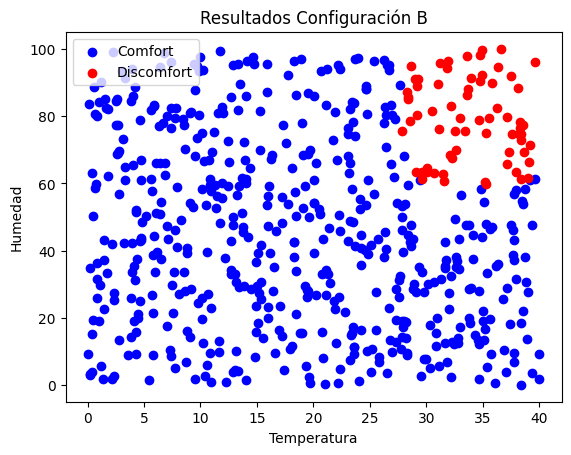

In [19]:
plt.scatter(X_test[y_predB==0][:,0], X_test[y_predB==0][:,1], c='blue', label='Comfort')
plt.scatter(X_test[y_predB==1][:,0], X_test[y_predB==1][:,1], c='red', label='Discomfort')
plt.xlabel("Temperatura")
plt.ylabel("Humedad")
plt.title("Resultados Configuración B")
plt.legend()
plt.show()


### Resultados de la Configuración B

La distribución de los puntos ayuda a entender por qué la Configuración B obtuvo un rendimiento tan alto:

La zona de disconfort está bien definida y más separada del resto de los datos que en la configuración anterior.

Esto facilita que el modelo aprenda una frontera más clara entre ambas clases.

La normalización y los ajustes del modelo probablemente ayudaron a capturar mejor esta relación conjunta entre temperatura y humedad.

### Comparación final de F1 entre Configuración A y B

En esta celda comparamos directamente el valor F1 de ambas configuraciones.  
El modelo con mayor F1 es el que mejor equilibrio logra entre precisión y recall, y por tanto el que mejor clasifica los datos.

Esta comparación nos permite decidir cuál configuración es más adecuada para este problema.


In [20]:
print("Comparación de F1:")
print("A:", f1_score(y_test, y_predA))
print("B:", f1_score(y_test, y_predB))

Comparación de F1:
A: 0.7796610169491526
B: 0.9558823529411765


### Discusión final sobre las configuraciones A y B

En esta práctica se han entrenado dos configuraciones distintas de redes neuronales MLP para clasificar condiciones de *comfort* y *discomfort* a partir de temperatura y humedad. Aunque ambas configuraciones han obtenido buenos resultados debido a que la frontera de decisión del problema es sencilla y los datos están generados de forma determinista, existen diferencias claras en su rendimiento.

La **Configuración A** utiliza una arquitectura más simple, con dos capas ocultas pequeñas (8 y 4 neuronas), función de activación *ReLU* y el optimizador *Adam*. Este modelo alcanza un valor F1 de **0.779**, lo que indica un rendimiento alto y una buena capacidad para separar ambas clases. Sin embargo, su capacidad de representación es limitada debido a su menor profundidad y menor número de neuronas.

La **Configuración B**, en cambio, emplea una arquitectura más compleja con tres capas ocultas (20, 10 y 5 neuronas), función de activación *tanh* y el optimizador *lbfgs*, que suele converger mejor en problemas pequeños y bien definidos. Este modelo obtiene un valor F1 de **0.955**, superando claramente a la Configuración A. Esto demuestra que la red B es capaz de ajustar mejor la frontera de decisión y generalizar con mayor precisión sobre los datos de test.



Las principales razones por las que la Configuración B obtiene mejores resultados son:

- Mayor capacidad del modelo gracias a más capas y más neuronas.
- La activación *tanh* permite modelar transiciones más suaves entre clases.
- El optimizador *lbfgs* es muy eficaz en datasets pequeños y sin ruido.
- Un mayor número de iteraciones facilita una convergencia más completa.

La **Configuración B** demuestra un rendimiento superior porque cuenta con una arquitectura más profunda y con mayor número de neuronas, lo que le permite aprender una frontera de decisión más precisa entre comfort y discomfort. Además, la activación tanh facilita transiciones más suaves entre clases, y el optimizador lbfgs resulta especialmente eficaz en datasets pequeños y bien definidos como el de esta práctica, logrando una convergencia más estable que Adam. Gracias a esta combinación de mayor capacidad del modelo, mejor función de activación y un optimizador más adecuado, la Configuración B obtiene métricas significativamente más altas, especialmente en la F1, lo que confirma su mejor capacidad de generalización y su rendimiento más robusto frente a la Configuración A.

Un dataset se considera pequeño cuando tiene menos de 10 000 muestras, pocas características en este caso solo 2: temperatura y humedad)y una frontera de decisión relativamente simple.

In [22]:
from google.colab import files
import joblib

# Asumiendo que tu modelo entrenado se llama 'mlp'
# Guarda el modelo en un archivo
joblib.dump(clf, 'modelo_cosecha.pkl')
print("Modelo guardado con éxito.")
files.download('modelo_cosecha.pkl')

Modelo guardado con éxito.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>